<a href="https://colab.research.google.com/github/IsaacFigNewton/SMIED/blob/main/Text2AMR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install deps

In [ ]:
!pip install amrlib penman torch transformers unidecode

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.3/353.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 19.6 MB/s eta 0:00:00
  Created wheel for smatch: filename=smatch-1.0.4-py3-none-any.whl size=24133 sha256=052cfd5a5db2f52010efad0b449a4e1537382a58a11c6b69723b98e73dc88620
  Stored in directory: /root/.cache/pip/wheels/33/d8/1e/c9ce3b7a4c71d5fcaadd8026e13bf1774045b4069dcb1cacd5
Successfully built smatch


# Import and config

In [ ]:
# Use
import os
import sys
import subprocess
import urllib.request
import tarfile
from pathlib import Path
import amrlib
import pprint

# Test AMRlib parsing

In [ ]:
# Setup paths
import amrlib
data_path = Path(amrlib.__file__).parent / 'data'
data_path.mkdir(exist_ok=True)
model_dir = data_path / 'model_parse_xfm_bart_base-v0_1_0'

# Download model if needed
if not model_dir.exists() and not (data_path / 'model_stog').exists():
    print("Downloading model (400MB)...")
    tar_path = data_path / 'model.tar.gz'
    urllib.request.urlretrieve(
        "https://github.com/bjascob/amrlib-models/releases/download/parse_xfm_bart_base-v0_1_0/model_parse_xfm_bart_base-v0_1_0.tar.gz",
        tar_path
    )
    tarfile.open(tar_path).extractall(data_path)
    tar_path.unlink()

    # Create symlink or rename
    import os
    if os.name == 'nt':
        model_dir.rename(data_path / 'model_stog')
    else:
        os.symlink(model_dir, data_path / 'model_stog')

/tmp/ipython-input-3005926204.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarfile.open(tar_path).extractall(data_path)


## Load model

In [ ]:
# Test
print("Loading model...")
parser = amrlib.load_stog_model()

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Parse AMR from text

In [ ]:
import time
start = time.time()
amr = parser.parse_sents([test])[0]
end = time.time()
print(f"Took {end - start} seconds")

Took 136.48318719863892 seconds


## Display, clean output

In [ ]:
clean_amr = amr[len(test):]
clean_amr = amr[amr.index("(m / multi-sentence\n"):]
pprint.pprint(clean_amr)

('(m / multi-sentence\n'
 '      :snt1 (r / report-01\n'
 '            :ARG0 (p / person\n'
 '                  :name (n / name\n'
 '                        :op1 "Mr."\n'
 '                        :op2 "Doo"))\n'
 '            :ARG1 (a / attempt-01\n'
 '                  :ARG0 (p2 / person\n'
 '                        :ARG0-of (c / call-02)\n'
 '                        :mod (m2 / male))\n'
 '                  :ARG1 (ii / intimidate-01\n'
 '                        :ARG0 p2\n'
 '                        :ARG1 p)\n'
 '                  :time (d / date-entity\n'
 '                        :year 2023\n'
 '                        :month 4\n'
 '                        :day 12)\n'
 '                  :ARG1-of (m3 / mean-01\n'
 '                        :ARG2 (s / say-01\n'
 '                              :ARG0 p2\n'
 '                              :ARG1 (a2 / and\n'
 '                                    :op1 (h / have-condition-91\n'
 '                                          :ARG1 (k / keep-01\

## Parse into AMR graph

In [ ]:
import penman

# Convert to edge list
graph = penman.decode(clean_amr)
edge_list = [(t[0], t[1], t[2]) for t in graph.triples]

# Print edges
for source, relation, target in edge_list:
    print(f"({source}, {relation}, {target})")

(m, :instance, multi-sentence)
(m, :snt1, r)
(r, :instance, report-01)
(r, :ARG0, p)
(p, :instance, person)
(p, :name, n)
(n, :instance, name)
(n, :op1, "Mr.")
(n, :op2, "Doo")
(r, :ARG1, a)
(a, :instance, attempt-01)
(a, :ARG0, p2)
(p2, :instance, person)
(c, :ARG0, p2)
(c, :instance, call-02)
(p2, :mod, m2)
(m2, :instance, male)
(a, :ARG1, ii)
(ii, :instance, intimidate-01)
(ii, :ARG0, p2)
(ii, :ARG1, p)
(a, :time, d)
(d, :instance, date-entity)
(d, :year, 2023)
(d, :month, 4)
(d, :day, 12)
(m3, :ARG1, a)
(m3, :instance, mean-01)
(m3, :ARG2, s)
(s, :instance, say-01)
(s, :ARG0, p2)
(s, :ARG1, a2)
(a2, :instance, and)
(a2, :op1, h)
(h, :instance, have-condition-91)
(h, :ARG1, k)
(k, :instance, keep-01)
(k, :ARG0, y)
(y, :instance, you)
(y, :part, m4)
(m4, :instance, mouth)
(k, :ARG1, s2)
(s2, :instance, shut-01)
(s2, :ARG0, y)
(s2, :ARG1, m4)
(h, :ARG2, k2)
(k2, :instance, know-01)
(k2, :ARG0, y)
(k2, :ARG1, o)
(o, :instance, or)
(o, :op1, e)
(e, :instance, enter-01)
(e, :ARG0, y)
(l,

## Visualize AMR graph

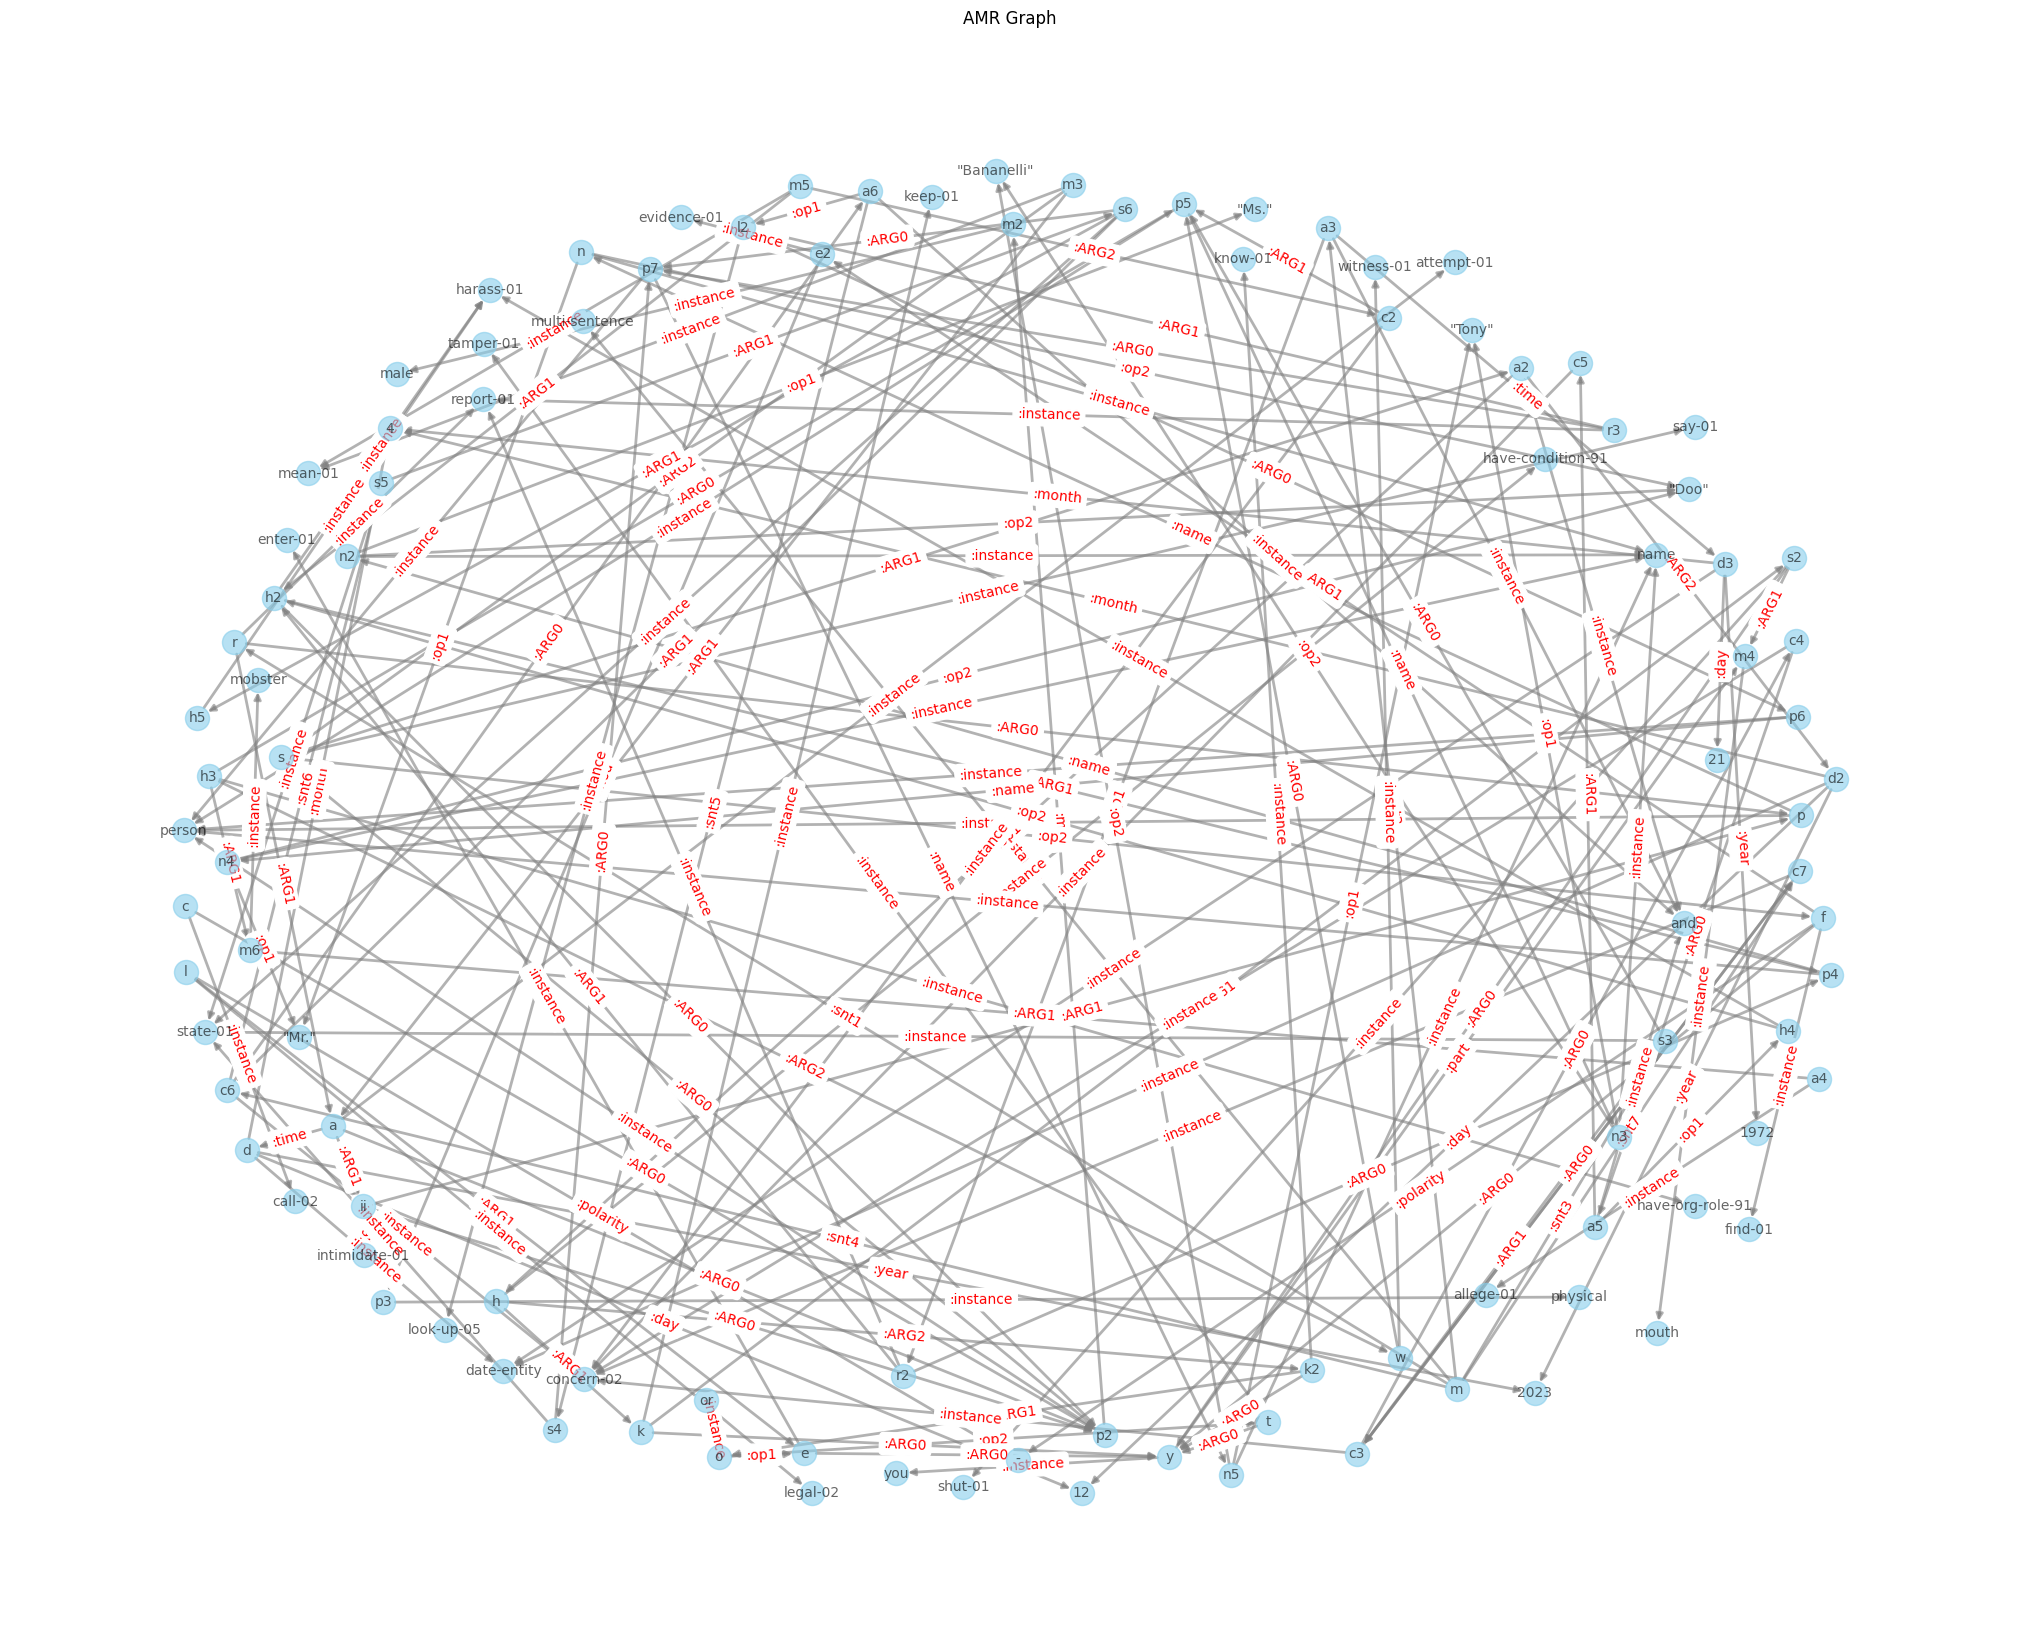

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges from edge_list
for source, relation, target in edge_list:
    G.add_edge(source, target, relation=relation)

# Draw the graph
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=16)  # You can choose a different layout algorithm
nx.draw(G, pos, with_labels=True, node_size=300, node_color="skyblue", font_size=10, width=2, edge_color="gray", alpha=0.6)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("AMR Graph")
plt.show()

# Test AMRlib SpaCy component

In [ ]:
import amrlib
import spacy
amrlib.setup_spacy_extension()
nlp = spacy.load('en_core_web_sm')
doc = nlp('The quick brown fox jumped over the lazy dog. Later, the fox ran into a different dog. The dogs started fighting.')

# The following are roughly equivalent but demonstrate the different objects.
graphs = doc._.to_amr()
for graph in graphs:
    print(graph)

for span in doc.sents:
    graphs = span._.to_amr()
    print(graphs[0])

# ::snt The quick brown fox jumped over the lazy dog.
(j / jump-03
      :ARG0 (f / fox
            :ARG1-of (q / quick-02)
            :mod (b / brown))
      :path (o / over
            :op1 (d / dog
                  :mod (l / lazy))))
# ::snt Later, the fox ran into a different dog.
(r / run-02
      :ARG0 (f / fox)
      :ARG1 (d / dog
            :ARG1-of (d2 / differ-02))
      :time (a / after))
# ::snt The dogs started fighting.
(s / start-01
      :ARG0 (d / dog)
      :ARG1 (f / fight-01
            :ARG0 d))
# ::snt The quick brown fox jumped over the lazy dog.
(j / jump-03
      :ARG0 (f / fox
            :ARG1-of (q / quick-02)
            :mod (b / brown))
      :path (o / over
            :op1 (d / dog
                  :mod (l / lazy))))
# ::snt Later, the fox ran into a different dog.
(r / run-02
      :ARG0 (f / fox)
      :ARG1 (d / dog
            :ARG1-of (d2 / differ-02))
      :time (a / after))
# ::snt The dogs started fighting.
(s / start-01
      :ARG0 (d / d

# Test CAMR SpaCy dependency + AMR parsing

In [9]:
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cu117.html

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu117.html
  Using cached torch_scatter-2.1.2.tar.gz (108 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [1]:
!uv python install 3.10.0
!python -m pip install pip==24.0

Installed Python 3.10.0 in 3.57s
 + cpython-3.10.0-linux-x86_64-gnu (python3.10)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 15.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
!pip install torch-scatter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=640889 sha256=a0df73545e60e53b6cbe90bada13f1a7f759909c26a6d618c305e29fd0cdc5bd
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch-scatter


In [3]:
!git clone https://github.com/IBM/transition-amr-parser.git

!pip install -e /content/transition-amr-parser

Cloning into 'transition-amr-parser'...
remote: Enumerating objects: 15343, done.
remote: Counting objects: 100% (1625/1625), done.
remote: Compressing objects: 100% (1073/1073), done.
remote: Total 15343 (delta 839), reused 553 (delta 552), pack-reused 13718 (from 1)
Receiving objects: 100% (15343/15343), 5.71 MiB | 10.86 MiB/s, done.
Resolving deltas: 100% (11526/11526), done.
Obtaining file:///content/transition-amr-parser
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for transition_neural_parser (pyproject.toml) ... done
  Created wheel for transition_neural_parser: filename=transition_neural_parser-0.5.4-0.editable-py3-none-any.whl size=9319 sha256=d3f8f42f85d4ff4b99e74baa1f59db364a87447b8ca7b5920e82e7732b7cdc9a
  Stored in directory: /tmp/pip-ephem-wheel-cache-6vvju4be/wheels/c5/f8/be/b6b8fca0f93a86b9

In [4]:
!pip install omegaconf==2.0.5 ipdb fairseq==0.12.2

DEPRECATION: omegaconf 2.0.5 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
  Attempting uninstall: omegaconf
    Found existing installation: omegaconf 2.3.0
    Uninstalling omegaconf-2.3.0:
      Successfully uninstalled omegaconf-2.3.0


In [5]:
!pip install ipdb fairseq==0.12.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 60.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.3/339.3 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.1 MB/s eta 0:00:00
  Created wheel for fairseq: filename=fairseq-0.12.2-cp312-cp312-linux_x86_64.whl size=11324511 sha256=374e50565883b9ebca688bc4a584fbc905388df181e181cb5c850e47d7d4929b
  Stored in directory: /root/.cache/pip/wheels/33/f8/a7

In [6]:
from transition_amr_parser.parse import AMRParser

# Download and save a model named AMR3.0 to cache
parser = AMRParser.from_pretrained('AMR3-structbart-L')
tokens, positions = parser.tokenize('The girl travels and visits places')

# Use parse_sentence() for single sentences or parse_sentences() for a batch
annotations, machines = parser.parse_sentence(tokens)

# Print Penman notation
print(annotations)

# Print Penman notation without JAMR, with ISI
amr = machines.get_amr()
print(amr.to_penman(jamr=False, isi=True))

# Plot the graph (requires matplotlib)
amr.plot()

ModuleNotFoundError: No module named 'transition_amr_parser'